In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv


In [2]:

# TASK 3: CUSTOMER CHURN PREDICTION
# Predict which bank customers are likely to leave


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported!")

 All libraries imported!


In [3]:
# STEP 1: LOAD THE DATASET
# 
# 10,000 bank customers with info like age, balance,
# credit score, and whether they left the bank (Exited)

df = pd.read_csv('/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv')
print(" Dataset loaded! Shape:", df.shape)


 Dataset loaded! Shape: (10000, 14)


In [4]:
# STEP 2: EXPLORE THE DATASET
# 
# Look at column names and data types
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())



Column names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Basic statistics:
         RowNumber    CustomerId   CreditScore       

In [5]:
# STEP 3: DROP UNNECESSARY COLUMNS
# 
# RowNumber, CustomerId, Surname don't help predict churn
# They are just identifiers, not useful features

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("\n Unnecessary columns dropped!")
print("New shape:", df.shape)



 Unnecessary columns dropped!
New shape: (10000, 11)


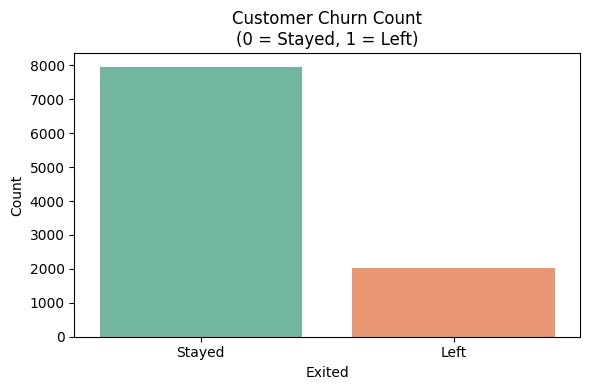

In [6]:
# STEP 4: VISUALIZATIONS (before encoding)
# 

# Plot 1: How many customers churned vs stayed?
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited',
              palette='Set2')
plt.title('Customer Churn Count\n(0 = Stayed, 1 = Left)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.tight_layout()
plt.show()


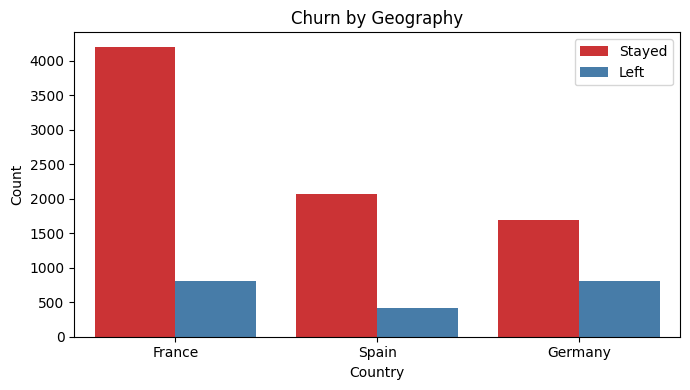

In [7]:
# Plot 2: Churn by Geography 
# Does location affect whether a customer leaves?
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Geography',
              hue='Exited', palette='Set1')
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.show()

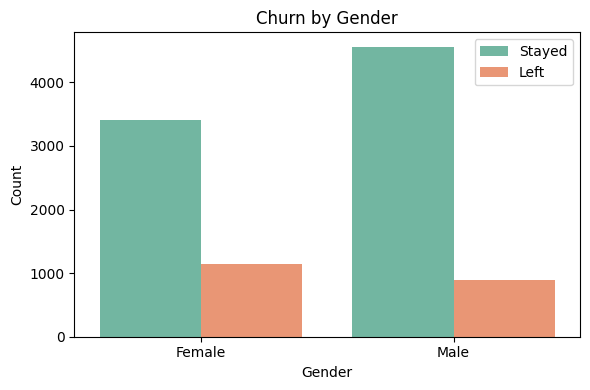

In [8]:
#  Plot 3: Churn by Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender',
              hue='Exited', palette='Set2')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.show()



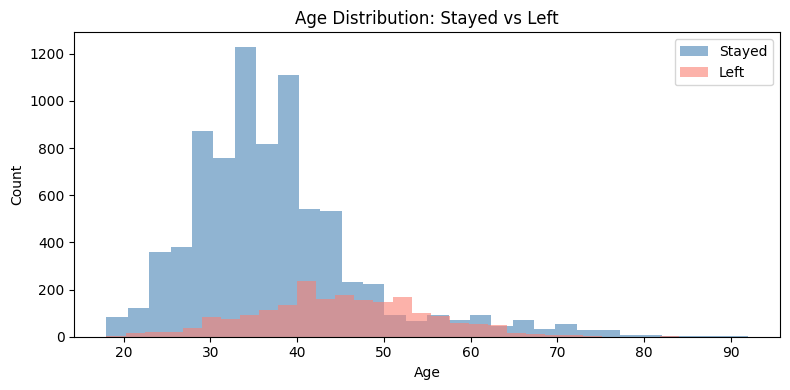

In [9]:
#Plot 4: Age distribution of churned vs stayed 
# Older customers tend to churn more
plt.figure(figsize=(8, 4))
df[df['Exited'] == 0]['Age'].plot(kind='hist', bins=30,
                                   alpha=0.6, color='steelblue',
                                   label='Stayed')
df[df['Exited'] == 1]['Age'].plot(kind='hist', bins=30,
                                   alpha=0.6, color='salmon',
                                   label='Left')
plt.title('Age Distribution: Stayed vs Left')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

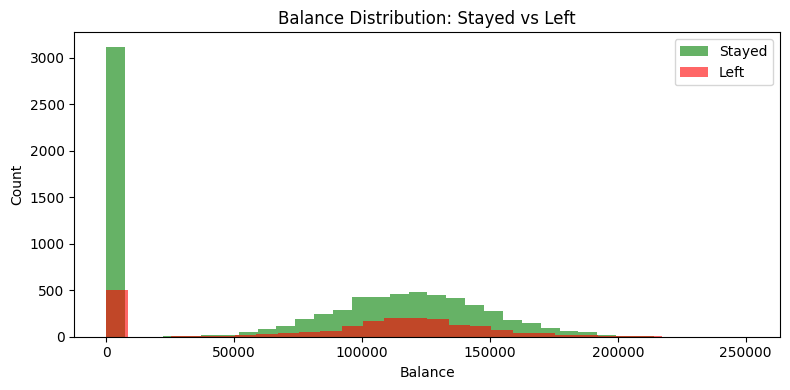

In [10]:
# Plot 5: Balance distribution
plt.figure(figsize=(8, 4))
df[df['Exited'] == 0]['Balance'].plot(kind='hist', bins=30,
                                       alpha=0.6, color='green',
                                       label='Stayed')
df[df['Exited'] == 1]['Balance'].plot(kind='hist', bins=30,
                                       alpha=0.6, color='red',
                                       label='Left')
plt.title('Balance Distribution: Stayed vs Left')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# STEP 5: ENCODE CATEGORICAL COLUMNS
# 
# Machine learning models need numbers, not text
# Geography: France/Spain/Germany → 0/1/2
# Gender: Male/Female → 0/1

le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])
print("\n Encoding done!")
print(df[['Geography', 'Gender']].head())



 Encoding done!
   Geography  Gender
0          0       0
1          2       0
2          0       0
3          0       0
4          2       0


In [12]:
# STEP 6: PREPARE FEATURES AND TARGET
# 
# X = all columns except what we want to predict
# y = Exited column (0 = stayed, 1 = left)

X = df.drop(columns=['Exited'])
y = df['Exited']
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)



Features shape: (10000, 10)
Target shape: (10000,)


In [13]:
# STEP 7: SCALE THE FEATURES
# 
# StandardScaler makes all numbers on the same scale
# For example: Age (20-90) and Balance (0-250000)
# are very different ranges — scaling fixes this
# This helps Logistic Regression perform better

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n Scaling done!")



 Scaling done!


In [14]:
# STEP 8: SPLIT DATA INTO TRAIN AND TEST
# 
# 80% for training, 20% for testing
# random_state=42 ensures same split every run

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
print(" Train samples:", X_train.shape[0])
print(" Test samples:", X_test.shape[0])

 Train samples: 8000
 Test samples: 2000


In [15]:
# STEP 9: TRAIN MODELS


# Model 1: Logistic Regression
# Good for simple binary classification problems
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"\n Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")



 Logistic Regression Accuracy: 81.55%


In [16]:
#  Model 2: Decision Tree
# Makes decisions using if/else rules like a flowchart
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f" Decision Tree Accuracy: {dt_accuracy*100:.2f}%")


 Decision Tree Accuracy: 78.10%


In [17]:
#Model 3: Random Forest
# A collection of many decision trees working together
# Usually the most accurate of the three
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f" Random Forest Accuracy: {rf_accuracy*100:.2f}%")



 Random Forest Accuracy: 86.40%


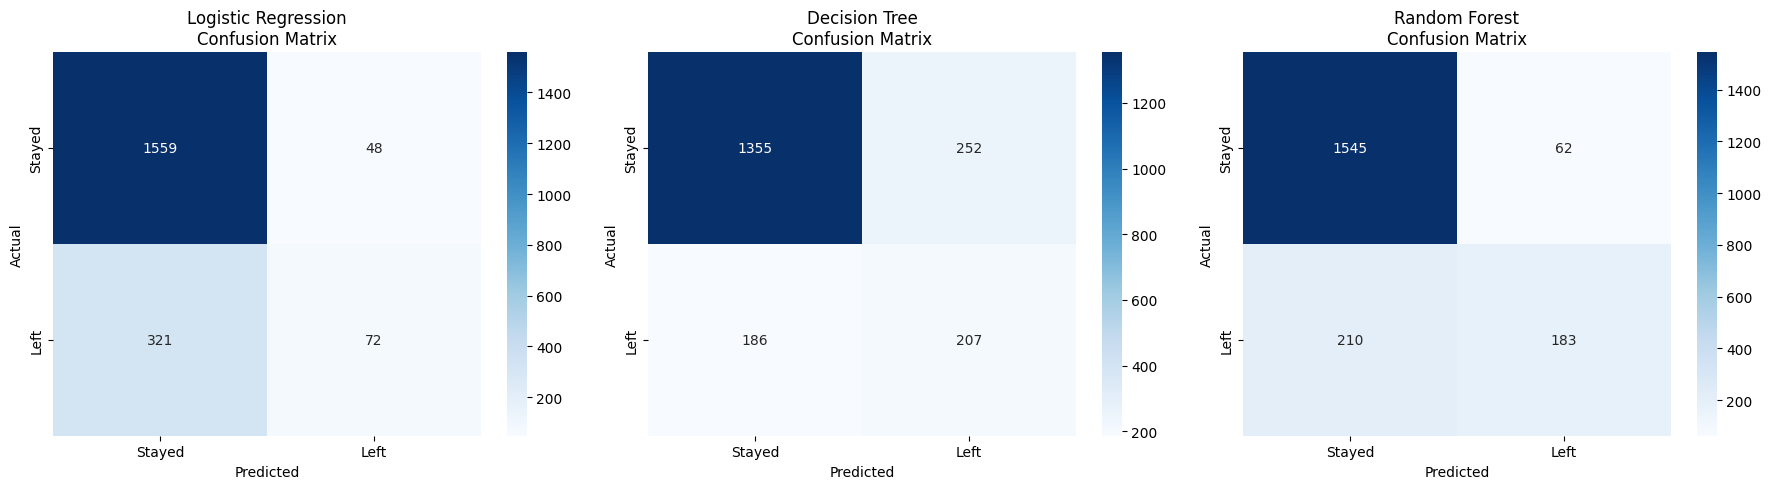

In [18]:
# STEP 10: CONFUSION MATRICES

# Shows how many predictions were correct/wrong

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in zip(axes,
    [lr_predictions, dt_predictions, rf_predictions],
    ['Logistic Regression', 'Decision Tree', 'Random Forest']):

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'],
                yticklabels=['Stayed', 'Left'])
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

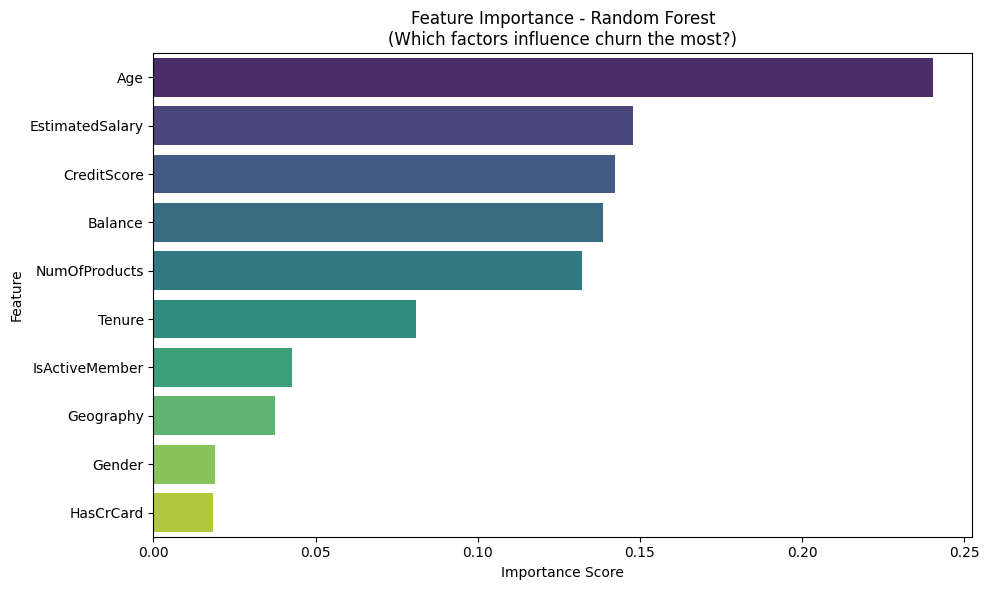


Top 3 most important features:
        Feature  Importance
            Age    0.240453
EstimatedSalary    0.148004
    CreditScore    0.142369


In [19]:
# STEP 11: FEATURE IMPORTANCE
# Random Forest can tell us which features matter most
# for predicting whether a customer will leave

feature_names = df.drop(columns=['Exited']).columns
importances = rf_model.feature_importances_

# Create a dataframe for easy plotting
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest\n(Which factors influence churn the most?)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(feat_df.head(3).to_string(index=False))

In [20]:

# STEP 12: CLASSIFICATION REPORTS


print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, lr_predictions,
      target_names=['Stayed', 'Left']))

print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_predictions,
      target_names=['Stayed', 'Left']))

print("=== Random Forest Report ===")
print(classification_report(y_test, rf_predictions,
      target_names=['Stayed', 'Left']))

print("\n Task 3 Complete!")


=== Logistic Regression Report ===
              precision    recall  f1-score   support

      Stayed       0.83      0.97      0.89      1607
        Left       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000

=== Decision Tree Report ===
              precision    recall  f1-score   support

      Stayed       0.88      0.84      0.86      1607
        Left       0.45      0.53      0.49       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.80      0.78      0.79      2000

=== Random Forest Report ===
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1607
        Left       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71 

## Conclusion

### Project Summary
In this task, we built a Customer Churn Prediction model to identify which bank 
customers are likely to leave. We used the Churn Modelling Dataset containing 
10,000 bank customers with 14 features including age, credit score, balance, 
geography, gender, and activity status.

### Dataset Overview
- Total customers: 10,000
- Total features: 14 (reduced to 11 after dropping unnecessary columns)
- No missing values were found — the dataset was already clean!
- About 20.37% of customers churned (left the bank), while 79.63% stayed.
  This means the dataset is imbalanced — more customers stayed than left.

### Dropped Columns
We removed 3 columns that were not useful for prediction:
- RowNumber — just a serial number
- CustomerId — just a unique ID
- Surname — a customer's name has no effect on whether they leave

### Key Observations from Visualizations
- More customers stayed than left, confirming the class imbalance.
- Germany had a higher churn rate compared to France and Spain.
- Female customers churned slightly more than male customers.
- Older customers (40-60 age group) were more likely to leave the bank
  compared to younger customers.
- Customers with higher balances were more likely to churn, which is
  surprising and could indicate dissatisfaction with services.

### Encoding
Two categorical (text) columns were converted to numbers:
- Geography: France=0, Germany=1, Spain=2
- Gender: Female=0, Male=1

### Feature Scaling
StandardScaler was applied to bring all features to the same scale.
This is important because features like Balance (0-250,000) and 
Age (18-92) have very different ranges, which can confuse some models.

### Model Performance
We trained and compared three classification models:

1. Logistic Regression:
   - Accuracy: 81.55%
   - Very good at identifying customers who stay (97% recall)
   - Poor at identifying customers who will leave (only 18% recall)
   - Simple and fast but misses too many churning customers

2. Decision Tree:
   - Accuracy: 78.10%
   - More balanced between stayed and left predictions
   - Better at catching churning customers than Logistic Regression
   - But lowest overall accuracy of the three models

3. Random Forest:
   - Accuracy: 86.40% ← BEST MODEL
   - Strong at identifying staying customers (96% recall)
   - Better churn detection than Logistic Regression (47% recall)
   - Most reliable and consistent model overall

### Feature Importance (Random Forest)
The top 3 most important features for predicting churn were:
1. Age (0.240) — the most powerful predictor. Older customers 
   are significantly more likely to leave.
2. Estimated Salary (0.148) — higher earners may have more 
   options and switch banks more easily.
3. Credit Score (0.142) — customers with lower credit scores 
   may be more financially stressed and likely to leave.

Other important features included Balance and Number of Products.

### What Could Be Improved
- The dataset is imbalanced (80% stayed, 20% left). Techniques like 
  SMOTE could be used to balance the classes and improve churn detection.
- Hyperparameter tuning on Random Forest (adjusting n_estimators, 
  max_depth) could push accuracy even higher.
- Adding more features like customer complaints, transaction history,
  and customer service interactions would improve predictions.
- XGBoost or Neural Networks could be tested for even better results.

### Final Verdict
Random Forest is the best model for this task with 86.40% accuracy. 
Age is the single most important factor in customer churn — banks 
should pay special attention to older customers and offer them 
better retention deals. Germany shows the highest churn rate 
geographically, suggesting region-specific retention strategies 
are needed.